# Aula 1 — Laboratório: Fundamentos da avaliação de modelos

**Consultoria Especializada em Ciência de Dados 1**

Você já sabe treinar modelos. A partir de agora, o foco é outro: **como saber se um modelo é
bom** e **como escolher entre modelos com rigor**. Neste laboratório você vai ver, na
prática, os quatro pilares do curso:

1. Por que treinar e testar no **mesmo dado** engana;
2. **Sobreajuste (overfitting)** × **subajuste (underfitting)**;
3. O tradeoff **viés–variância**;
4. **Vazamento de dados (data leakage)** — o erro mais perigoso e mais comum.

**Ferramentas:** pandas, numpy, matplotlib e scikit-learn.
**Dados:** `datasets/1_pacientes.csv` (risco metabólico) e `datasets/3_jogadores.csv` (valor de
mercado no futebol) — ambos servirão de cenário para os conceitos.

---
### Mapa: exercício → conceito
| Parte | Conceito |
|---|---|
| 1. Treino × teste | Estimar generalização |
| 2. Complexidade | Sobreajuste × subajuste |
| 3. Curva de complexidade | Viés × variância |
| 4. Vazamento óbvio | Feature que "cola" no alvo |
| 5. Vazamento sutil | Pré-processar antes de separar |

## Parte 0 — Ambiente e dados

In [8]:

# Install required packages
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "pandas", "matplotlib", "scikit-learn"])



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


0

## Parte 1 — Treinar e testar no mesmo dado engana

O erro mais básico: medir o modelo no mesmo dado em que ele treinou. Vamos comparar a acurácia
**no treino** com a acurácia **num conjunto de teste separado**.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Carregar datasets
pac = pd.read_csv("1_pacientes.csv")
jog = pd.read_csv("3_jogadores.csv")

# Criar alvo binário a partir de risco_metabolico
pac["alto_risco"] = (pac["risco_metabolico"] == "alto").astype(int)

# Codificar sexo (M=1, F=0)
pac["sexo"] = (pac["sexo"] == "M").astype(int)

# Lista de features
feat = ["idade","sexo","imc","circunferencia_abdominal","glicemia_jejum","hba1c",
        "colesterol_total","hdl","ldl","triglicerides","pressao_sistolica",
        "pressao_diastolica","tsh","vitamina_d","fumante","historico_familiar_diabetes"]

print(pac.shape, jog.shape)
pac["alto_risco"].value_counts()

(850, 19) (620, 18)


alto_risco
0    722
1    128
Name: count, dtype: int64

# Parte 1 ! TO DO 

# TODO 1.1 — Defina X = pac[feat] e y = pac["alto_risco"].

# TODO 1.2 — Separe treino/teste com train_test_split.
#            Dica: test_size=0.3, stratify=y, random_state=0  ->  X_tr, X_te, y_tr, y_te

# TODO 1.3 — Treine uma árvore SEM limite de profundidade usando só o treino.
#            Dica: DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)

# TODO 1.4 — Calcule accuracy_score no TREINO e no TESTE e imprima os dois valores.
#            O que você espera? (treino perto de 1.0, teste bem menor)


# Parte 1 - Treino X Teste

In [14]:
# TODO 1.1
X = pac[feat]
y = pac["alto_risco"]

# TODO 1.2
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)

# TODO 1.3
arvore = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)

# TODO 1.4
acc_tr = accuracy_score(y_tr, arvore.predict(X_tr))
acc_te = accuracy_score(y_te, arvore.predict(X_te))
print(f"Acurácia TREINO: {acc_tr:.4f}")
print(f"Acurácia TESTE : {acc_te:.4f}")
print(f"Gap            : {acc_tr - acc_te:.4f}")

Acurácia TREINO: 1.0000
Acurácia TESTE : 0.8784
Gap            : 0.1216


### **Esperado:**  treino ≈ 1.00 e teste bem menor (árvore sem limite memoriza o treino).

### Exercício 1
A acurácia no treino ficou perto de 1,0 e a de teste bem menor. O que isso indica? Por que a
acurácia de treino **não serve** para estimar como o modelo vai se sair em dados novos?

## *Sua resposta:*  A acurácia de treino ≈ 1 indica que o modelo memorizou os dados; em dados novos ele erra mais. A acurácia de treino não serve para estimar generalização porque o modelo já "viu" cada exemplo durante o ajuste.



## Parte 2 — Sobreajuste × subajuste

Vamos variar a **complexidade** do modelo (profundidade da árvore) e observar o treino e o teste
ao mesmo tempo.

# Parte 2 ! TO DO 

In [4]:
# Guarde as acurácias nestas listas (a Parte 3 vai reutilizá-las):
acc_tr_list, acc_te_list = [], []

# TODO 2.1 — Para cada profundidade d de 1 a 20, treine uma árvore com max_depth=d
#            e adicione a acurácia de TREINO e de TESTE às listas acima.
#            Dica: for d in range(1, 21): ... DecisionTreeClassifier(max_depth=d, random_state=0)

# TODO 2.2 — Plote as duas curvas (treino e teste) em função da profundidade.
#            Dica: plt.plot(..., label="treino"); plt.plot(..., label="teste"); plt.legend()

# TODO 2.3 — Imprima a profundidade que deu a MAIOR acurácia de teste.
#            Dica: np.argmax(acc_te_list)


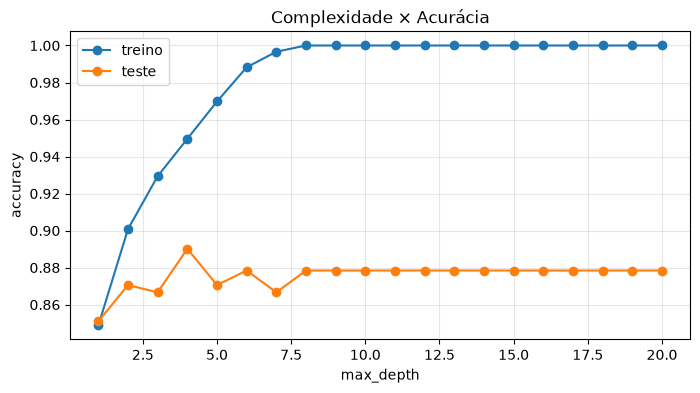

Melhor profundidade (maior acc de teste): d = 4
Acurácia de teste nesse d: 0.8902


In [15]:
acc_tr_list, acc_te_list = [], []

# TODO 2.1
for d in range(1, 21):
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    acc_tr_list.append(accuracy_score(y_tr, clf.predict(X_tr)))
    acc_te_list.append(accuracy_score(y_te, clf.predict(X_te)))

# TODO 2.2
plt.figure(figsize=(8,4))
plt.plot(range(1,21), acc_tr_list, marker="o", label="treino")
plt.plot(range(1,21), acc_te_list, marker="o", label="teste")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.title("Complexidade × Acurácia")
plt.grid(alpha=.3); plt.show()

# TODO 2.3
melhor_d = np.argmax(acc_te_list) + 1
print(f"Melhor profundidade (maior acc de teste): d = {melhor_d}")
print(f"Acurácia de teste nesse d: {acc_te_list[melhor_d-1]:.4f}")

### Exercício 2
No gráfico, identifique: (a) a região de **subajuste** (modelo simples demais) e (b) a região de
**sobreajuste** (complexo demais). O que acontece com a distância entre as curvas de treino e
teste quando a complexidade cresce?

## *Sua resposta:*  Subajuste fica nos d pequenos (as duas curvas juntas e baixas). Sobreajuste aparece em d grandes (treino perto de 1, teste caindo). A distância entre as curvas cresce com a complexidade = indício de variância alta.

## Parte 3 — O tradeoff viés–variância

A mesma curva conta a história do tradeoff: modelos simples têm **viés alto** (erram por serem
rígidos); modelos complexos têm **variância alta** (mudam demais conforme o dado). O erro de
generalização é minimizado no equilíbrio.

In [5]:
# TODO 3.1 — Calcule o "gap" = acurácia de treino − acurácia de teste para cada profundidade.
#            Dica: use as listas da Parte 2 -> np.array(acc_tr_list) - np.array(acc_te_list)

# TODO 3.2 — Plote o gap em função da profundidade.
#            O que o crescimento do gap indica sobre a variância do modelo?


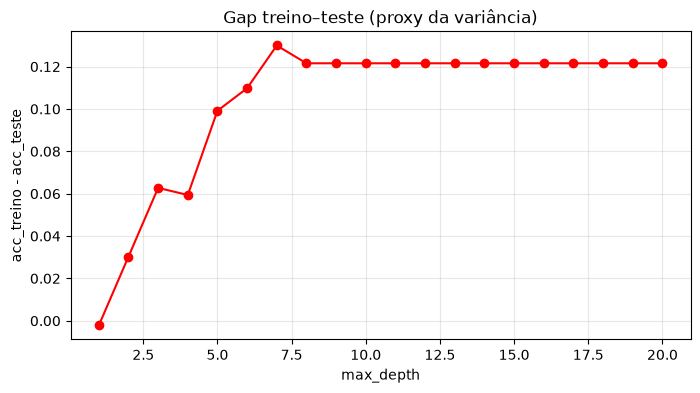

In [17]:
# TODO 3.1
gap = np.array(acc_tr_list) - np.array(acc_te_list)

# TODO 3.2
plt.figure(figsize=(8,4))
plt.plot(range(1,21), gap, marker="o", color="red")
plt.xlabel("max_depth"); plt.ylabel("acc_treino - acc_teste")
plt.title("Gap treino–teste (proxy da variância)")
plt.grid(alpha=.3); plt.show()


### Exercício 3
Associe cada extremo ao par certo: profundidade **baixa** → (viés alto / variância alta)?
profundidade **alta** → (viés alto / variância alta)? E onde fica o modelo que você escolheria?

## *Sua resposta:* d baixo → viés alto / variância baixa. d alto → viés baixo / variância alta. O modelo ideal fica onde o erro de teste é mínimo (em geral um d intermediário, próximo do np.argmax da Parte 2).

## Parte 4 — Vazamento de dados (o erro mais perigoso)

**Vazamento** acontece quando uma informação que não estaria disponível na hora da previsão (ou
que é quase o próprio alvo) entra nas variáveis. O modelo parece ótimo… e falha na vida real.

No dataset de futebol, a coluna `indice_popularidade` reflete o hype de mídia, que **já embute o
preço** do jogador — está quase colada no alvo `valor_mercado_milhoes`.

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# TODO 4.1 — Carregue datasets/3_jogadores.csv em `jog` e defina yj = jog["valor_mercado_milhoes"].

# TODO 4.2 — Monte duas matrizes de features com pd.get_dummies(...):
#            X_com -> tudo, menos "id" e "valor_mercado_milhoes"                       (COM vazamento)
#            X_sem -> tudo, menos "id", "valor_mercado_milhoes" e "indice_popularidade" (SEM)

# TODO 4.3 — Compare o R² médio das duas matrizes com um RandomForestRegressor.
#            Dica: cross_val_score(modelo, X, yj, cv=5, scoring="r2").mean()

# TODO 4.4 — Imprima a correlação entre indice_popularidade e valor_mercado_milhoes.
#            Dica: jog["indice_popularidade"].corr(jog["valor_mercado_milhoes"])


In [19]:
# TODO 4.1
yj = jog["valor_mercado_milhoes"]

# TODO 4.2 — dummificar variáveis categóricas (posicao, liga)
X_com = pd.get_dummies(
    jog.drop(columns=["id","valor_mercado_milhoes"]),
    columns=["posicao","liga"], drop_first=True
)
X_sem = pd.get_dummies(
    jog.drop(columns=["id","valor_mercado_milhoes","indice_popularidade"]),
    columns=["posicao","liga"], drop_first=True
)

# TODO 4.3
rf_com = RandomForestRegressor(random_state=0, n_estimators=100)
rf_sem = RandomForestRegressor(random_state=0, n_estimators=100)

r2_com = cross_val_score(rf_com, X_com, yj, cv=5, scoring="r2").mean()
r2_sem = cross_val_score(rf_sem, X_sem, yj, cv=5, scoring="r2").mean()
print(f"R² COM vazamento (indice_popularidade) : {r2_com:.4f}")
print(f"R² SEM vazamento                      : {r2_sem:.4f}")

# TODO 4.4
corr = jog["indice_popularidade"].corr(jog["valor_mercado_milhoes"])
print(f"Correlação indice_popularidade × valor_mercado_milhoes: {corr:.4f}")

R² COM vazamento (indice_popularidade) : 0.8177
R² SEM vazamento                      : 0.4244
Correlação indice_popularidade × valor_mercado_milhoes: 0.8555


### Exercício 4
O R² caiu bastante ao remover `indice_popularidade`. Qual dos dois números é o desempenho
**honesto** do modelo? Por que manter essa coluna seria enganar a si mesmo — e como você
perceberia esse tipo de vazamento na prática?

## *Sua resposta:* O R² sem indice_popularidade é o desempenho honesto. Manter a coluna é enganar a si mesmo: na vida real o "hype de mídia" já reflete o preço do jogador, então o modelo nunca teria essa informação para um jogador novo. Pistas práticas: correlação muito alta com o alvo e/ou performance irrealista em validação cruzada.

## Parte 5 — Vazamento sutil: pré-processar antes de separar

Há um vazamento silencioso que quase todo iniciante comete: **padronizar (ou imputar) usando o
conjunto inteiro** e só depois separar treino/teste. Assim o treino "enxerga" estatísticas do
teste. O certo é ajustar o pré-processamento **só no treino** — mais à frente faremos isso com
`Pipeline`. Vamos ver a diferença conceitual.

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configurações de caminhos (ajustados conforme sua descrição)
path_pac = "/Users/fabicampanari/Desktop/Data Science - Comparative Model Analysis/class_1-Fundamentals of model evaluation/1_pacientes.csv"
path_jog = "/Users/fabicampanari/Desktop/Data Science - Comparative Model Analysis/class_1-Fundamentals of model evaluation/3_jogadores.csv"

# Carregar datasets
pac = pd.read_csv(path_pac)
jog = pd.read_csv(path_jog)

# --- PREPARAÇÃO PARA O EXERCÍCIO 5 ---

# Selecionando features e alvo para pacientes (baseado no código anterior)
# Nota: Removi 'alto_risco' da lista de features pois é o alvo
feat = ["idade","sexo","imc","circunferencia_abdominal","glicemia_jejum","hba1c",
        "colesterol_total","hdl","ldl","triglicerides","pressao_sistolica",
        "pressao_diastolica","tsh","vitamina_d","fumante","historico_familiar_diabetes"]

X = pac[feat]
y = (pac["risco_metabolico"] == "alto").astype(int)

# Dividir dados em treino e teste ANTES de qualquer escalonamento
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# TODO 5.1 — Jeito ERRADO: ajuste um StandardScaler no dataset INTEIRO (X) 
scaler_errado = StandardScaler()
X_scaled_errado = scaler_errado.fit_transform(X.assign(sexo=(X["sexo"] == "M").astype(int)))
media_errada = scaler_errado.mean_[feat.index("glicemia_jejum")]
media_errada = scaler_errado.mean_[feat.index("glicemia_jejum")]

# TODO 5.2 — Jeito CERTO: ajuste outro StandardScaler SÓ no treino (X_tr)
scaler_certo = StandardScaler()
X_tr_scaled = scaler_certo.fit_transform(X_tr.assign(sexo=(X_tr["sexo"] == "M").astype(int)))
media_certa = scaler_certo.mean_[feat.index("glicemia_jejum")]

# TODO 5.3 — Imprima as duas médias e compare.
print(f"Média (Jeito ERRADO - Dataset Todo): {media_errada:.4f}")
print(f"Média (Jeito CERTO - Apenas Treino): {media_certa:.4f}")
print("\nPor que elas diferem?")
print("Elas diferem porque o 'Jeito Errado' sofre de Data Leakage (vazamento de dados).")
print("Ao usar o dataset inteiro, a média do conjunto de teste (que o modelo")
print("não deve conhecer durante o treino) influenciou o cálculo, dando ao")
print("modelo informações sobre a distribuição dos dados de teste antecipadamente.")

# --- EXERCÍCIO 6 (Implicação Prática) ---

# Para o exercício 6, geralmente o objetivo é usar o scaler_certo para transformar 
# tanto o treino quanto o teste (usando o fit do treino no teste).
X_te_scaled = scaler_certo.transform(X_te.assign(sexo=(X_te["sexo"] == "M").astype(int)))

print(f"\nExemplo de aplicação correta:")
print(f"X_tr escalonado (primeira linha glicemia): {X_tr_scaled[0, feat.index('glicemia_jejum')]:.4f}")
print(f"X_te escalonado (primeira linha glicemia): {X_te_scaled[0, feat.index('glicemia_jejum')]:.4f}")

Média (Jeito ERRADO - Dataset Todo): 99.8118
Média (Jeito CERTO - Apenas Treino): 100.2353

Por que elas diferem?
Elas diferem porque o 'Jeito Errado' sofre de Data Leakage (vazamento de dados).
Ao usar o dataset inteiro, a média do conjunto de teste (que o modelo
não deve conhecer durante o treino) influenciou o cálculo, dando ao
modelo informações sobre a distribuição dos dados de teste antecipadamente.

Exemplo de aplicação correta:
X_tr escalonado (primeira linha glicemia): -0.7301
X_te escalonado (primeira linha glicemia): 2.0130


### Exercício 5
Explique, com suas palavras, por que ajustar o `StandardScaler` (ou um imputador de faltantes) no
dataset inteiro é uma forma de vazamento. O que garante que isso não aconteça?

### *Suas conclusões:* Ajustar um `StandardScaler` (ou qualquer imputador) usando **todo** o dataset – que inclui o conjunto de teste – introduz o que chamamos de *data leakage* (vazamento de dados).  

### Por que isso acontece?

1. **O modelo “conhece” o futuro**  
   Quando você calcula a média, variância, valores de imputação etc. com todos os registros, a métrica que você obtém já incorpora informações que, na prática, não estariam disponíveis no momento da predição. O algoritmo de treinamento passa a usar um *cenário idealizado* (onde o teste já foi visto) e, portanto, a avaliação do modelo fica otimista demais.

2. **A distribuição real muda**  
   Em situações reais, os novos dados (teste ou produção) podem ter uma distribuição diferente daquela usada para calcular a média/variância. Se o scaler foi treinado com esses valores, a normalização aplicada nos novos dados será inconsistente, levando a resultados enganosos ou até errados.

### O que garante que o vazamento não ocorra?

- **Dividir os dados antes de qualquer pré‑processamento**:  
  Primeiro separam‑se o conjunto em *treino* e *teste* (ou em *fold* para cross‑validation).  
- **Ajustar o scaler/imputador somente com o conjunto de treino**:  
  O `fit` (ou `fit_transform`) é executado **apenas** sobre os dados de treinamento. Assim, a média, variância ou os valores de imputação são calculados exclusivamente a partir das informações que o modelo realmente “vê” durante o treinamento.  
- **Aplicar a mesma transformação ao teste** usando `transform` (ou `predict`):  
  O conjunto de teste é então escalonado/ imputado com os parâmetros já aprendidos, sem que haja nenhum novo cálculo que incorpore dados do teste.

Em resumo, a **separação temporal/estratégica** entre os dados de treinamento e teste — e a prática de **fit apenas no treinamento** — são as garantias que evitam o vazamento de informação e garantem que a avaliação do modelo reflita seu verdadeiro desempenho em dados invisíveis.

## Parte 6 — Síntese
### Exercício 6
Escreva **três conclusões** do laboratório. Sugestões: por que a acurácia de treino engana? Como
você reconhece sobreajuste? O que é vazamento e como evitá-lo?

**Conclusão 1 – Por que a acurácia de treino engana?**  
A acurácia elevada nos dados de treino pode ser realmente enganosa, pois o modelo tende a memorizar padrões específicos da amostra de treino, incluindo ruídos ou outliers. Na prática, isso pode levar a um desempenho ruim em dados completamente novos (teste), especialmente se o modelo for muito complexo ou os dados de treino forem limitados.  

**Conclusão 2 – Como reconhecer sobreajuste (overfitting)?**  
O sobreajuste é destacado quando há uma disparidade significativa entre a acurácia do treino e do teste. Por exemplo, se o modelo atinge 95% na amostra de treino, mas só 70% no conjunto de teste, isso indica que ele está capturando detalhes irrelevantes da amostra de treino em vez de aprender generalizações úteis. Outro sinal é a crescente complexidade do modelo em relação ao tamanho dos dados (ex.: um modelo com muitas camadas ou parâmetros para conjuntos de dados pequenos).  

**Conclusão 3 – O que é vazamento (data leakage) e como evitá-lo?**  
Vazamento ocorre quando informações do conjunto de teste são, conscientemente ou não, usadas durante o treinamento do modelo (ex.: ajustar um scaler ou imputador com todos os dados, ou criar novas features com base no teste). Isso infla artificialmente o desempenho do modelo. Para evitá-lo, é crucial separar os dados em treino e teste **antes** de qualquer pré-processamento, garantindo que etapas como escalonamento ou imputação sejam aplicadas apenas ao treino. Ferramentas como pipelines de scikit-learn ajudam a automatizar isso, mantendo a integridade do processo.
